In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
confusion_matrix,
classification_report
)

In [2]:
# Load dataset

df = pd.read_csv('/content/HR-Employee-Attrition.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# Working copy

model_df = df.copy()

In [4]:
# Feature Engineering

model_df['overtime_flag'] = (
model_df['OverTime']
.map({'No':0,'Yes':1})
)

model_df['tenure_years'] = (
model_df['YearsAtCompany']
)

model_df['salary_hike_pct'] = (
model_df['PercentSalaryHike']
)

model_df['burnout_score']=(

model_df['overtime_flag']*3

+

(5-model_df['WorkLifeBalance'])

+

(5-model_df['JobSatisfaction'])

)

In [6]:
# Target Encoding

model_df['attrition_flag']=(
model_df['Attrition']
.map({
'No':0,
'Yes':1
})
)

In [7]:
model_df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,overtime_flag,tenure_years,salary_hike_pct,burnout_score,attrition_flag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,6,4,0,5,1,6,11,8,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,10,7,1,7,0,10,23,5,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,0,0,0,0,1,0,15,7,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,8,7,3,0,1,8,11,7,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,2,2,2,2,0,2,12,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,5,2,0,3,0,5,17,3,0
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,3,7,7,1,7,0,7,15,6,0
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,3,6,2,0,3,1,6,20,8,0
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,2,9,6,0,8,0,9,14,6,0


In [8]:
# Drop unused columns

drop_cols=[

'Attrition',

'EmployeeCount',

'EmployeeNumber',

'Over18',

'StandardHours'

]

model_df=model_df.drop(
columns=drop_cols
)

In [9]:
# Encode categorical columns

encoder=LabelEncoder()

cat_cols=model_df.select_dtypes(
include='object'
).columns

for col in cat_cols:

    model_df[col]=encoder.fit_transform(
        model_df[col]
    )

model_df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,overtime_flag,tenure_years,salary_hike_pct,burnout_score,attrition_flag
0,41,2,1102,2,1,2,1,2,0,94,...,1,6,4,0,5,1,6,11,8,1
1,49,1,279,1,8,1,1,3,1,61,...,3,10,7,1,7,0,10,23,5,0
2,37,2,1373,1,2,2,4,4,1,92,...,3,0,0,0,0,1,0,15,7,1
3,33,1,1392,1,3,4,1,4,0,56,...,3,8,7,3,0,1,8,11,7,0
4,27,2,591,1,2,1,3,1,1,40,...,3,2,2,2,2,0,2,12,5,0


In [10]:
# Features and target

X=model_df.drop(
'attrition_flag',
axis=1
)

y=model_df['attrition_flag']

In [14]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [15]:
# Random Forest Baseline Model

rf = RandomForestClassifier(

    n_estimators=200,

    max_depth=8,

    random_state=42

)

rf.fit(

    X_train,

    y_train

)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [20]:
# Predictions

pred = rf.predict(X_test)

prob = rf.predict_proba(

    X_test

)[:,1]

# First 10 predictions

pred[:10]
prob[:10]

array([0.45677289, 0.06389432, 0.12299505, 0.05634981, 0.4367555 ,
       0.16644414, 0.09601459, 0.05622425, 0.03113776, 0.54517561])

In [21]:
print(

"Accuracy:",

accuracy_score(
y_test,
pred
)

)

print(

"Precision:",

precision_score(
y_test,
pred
)

)

print(

"Recall:",

recall_score(
y_test,
pred
)

)

print(

"F1 Score:",

f1_score(
y_test,
pred
)

)

print(

"ROC AUC:",

roc_auc_score(
y_test,
prob
)

)

Accuracy: 0.8469387755102041
Precision: 0.6
Recall: 0.1276595744680851
F1 Score: 0.21052631578947367
ROC AUC: 0.806615556895512


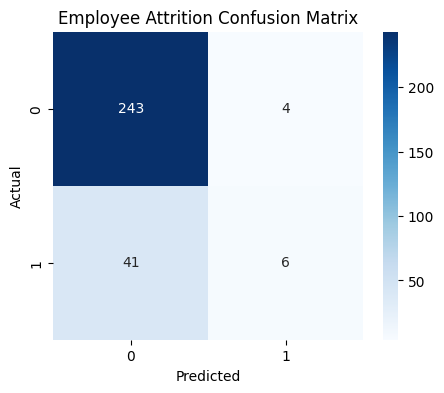

In [22]:
# Confusion Matrix

cm = confusion_matrix(

y_test,

pred

)

plt.figure(

figsize=(5,4)

)

sns.heatmap(

cm,

annot=True,

fmt='d',

cmap='Blues'

)

plt.xlabel(

'Predicted'

)

plt.ylabel(

'Actual'

)

plt.title(

'Employee Attrition Confusion Matrix'

)

plt.show()

In [23]:
# Feature Importance

importance = pd.DataFrame({

'Feature':X.columns,

'Importance':rf.feature_importances_

})

importance = importance.sort_values(

'Importance',

ascending=False

)

importance.head(10)

,Feature,Importance
15,MonthlyIncome,0.073408
0,Age,0.064838
33,burnout_score,0.062724
23,TotalWorkingYears,0.062252
2,DailyRate,0.047717
4,DistanceFromHome,0.042121
9,HourlyRate,0.037744
26,YearsAtCompany,0.036355
16,MonthlyRate,0.035679
31,tenure_years,0.034972


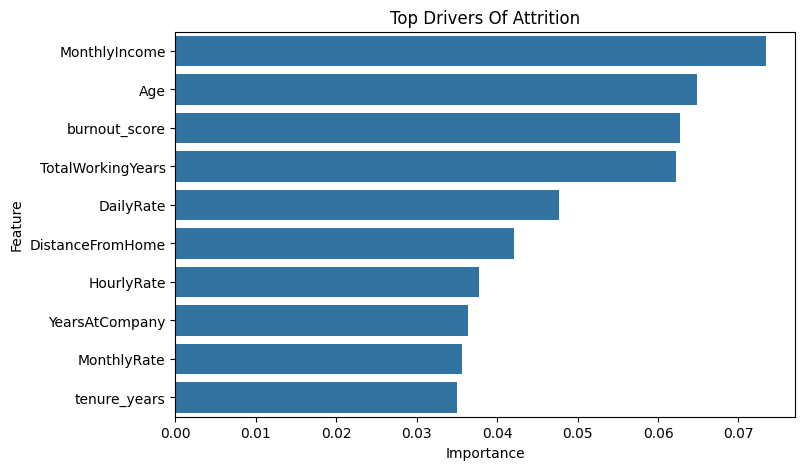

In [24]:
plt.figure(

figsize=(8,5)

)

sns.barplot(

data=importance.head(10),

x='Importance',

y='Feature'

)

plt.title(

'Top Drivers Of Attrition'

)

plt.show()

In [25]:
# Create prediction table

risk_df = X_test.copy()

risk_df['actual_attrition'] = y_test.values

risk_df['predicted_attrition'] = pred

risk_df['risk_score'] = (

prob * 100

).round(2)


In [26]:
# Sort highest risk employees

risk_df = risk_df.sort_values(

'risk_score',

ascending=False

)

risk_df.head(10)

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,overtime_flag,tenure_years,salary_hike_pct,burnout_score,actual_attrition,predicted_attrition,risk_score
688,19,2,419,2,21,3,4,4,1,37,...,0,0,0,1,1,13,7,1,1,90.88
911,25,1,599,2,24,1,1,3,1,73,...,0,1,0,1,1,14,6,1,1,75.09
711,29,2,906,1,10,3,1,4,0,92,...,0,0,0,1,0,20,9,1,1,72.25
301,18,2,812,2,10,3,3,4,0,69,...,0,0,0,0,0,12,4,0,1,66.36
1349,26,2,482,1,1,2,1,2,0,90,...,0,1,0,1,1,13,8,0,1,60.07
2,37,2,1373,1,2,2,4,4,1,92,...,0,0,0,1,0,15,7,1,1,55.89
762,26,1,342,1,2,3,1,1,1,57,...,2,1,2,1,3,14,9,1,1,55.60
357,21,1,756,2,1,1,5,1,0,99,...,2,1,2,1,3,11,8,1,1,54.55
1311,18,0,1431,1,14,3,3,2,0,33,...,0,0,0,0,0,16,6,0,1,54.52
17,22,0,1123,1,16,2,3,4,1,96,...,0,0,0,1,1,13,7,0,1,52.12


In [27]:
# Risk Category

risk_df['risk_level']=np.where(

risk_df['risk_score']>=80,

'High Risk',

np.where(

risk_df['risk_score']>=50,

'Medium Risk',

'Low Risk'

)

)

In [28]:
risk_df[
[
'risk_score',

'risk_level',

'actual_attrition',

'predicted_attrition'

]

].head(15)

,risk_score,risk_level,actual_attrition,predicted_attrition
688,90.88,High Risk,1,1
911,75.09,Medium Risk,1,1
711,72.25,Medium Risk,1,1
301,66.36,Medium Risk,0,1
1349,60.07,Medium Risk,0,1
2,55.89,Medium Risk,1,1
762,55.60,Medium Risk,1,1
357,54.55,Medium Risk,1,1
1311,54.52,Medium Risk,0,1
17,52.12,Medium Risk,0,1


## # Conclusion

A machine learning pipeline was developed to predict employee attrition risk using HR employee data.

Key steps completed:

- Feature engineering and target encoding
- Data preprocessing and categorical variable encoding
- Train-test split for model validation
- Random Forest baseline model training
- Performance evaluation using Accuracy, Precision, Recall, F1-Score, and ROC-AUC
- Employee risk probability generation
- High-risk employee identification

The model successfully transformed employee HR attributes into predictive insights, enabling proactive identification of employees with higher attrition risk.

The generated risk scores can help organizations take preventive actions before employee resignation occurs.